# TEST

# Aridity Index (AI)
Extract mean aridity index within a 10 km bounding box for each site.

Source: Zomer et al. (2022) Global Aridity Index v3.1
        https://doi.org/10.6084/m9.figshare.7504448

- Using Annual ETO version (ai_v31_yr.tif) which represents the mean annual aridity index.
- Raw values are stored as uint16 integers multiplied by 10,000.
- Divide by 10,000 to get the actual aridity index.
- Higher values = more humid; lower values = more arid.


In [1]:
# Libraries
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import from_bounds
import matplotlib.pyplot as plt
# Package for colors
import matplotlib.cm as cm
from scipy import stats #spearman rank correlation
from scipy.stats import spearmanr # Using for Spearman Rank Correlation

### AI for all combined 1, 4, 16, and 100 km^2 

In [11]:
# # Retrieving CSV and TIF from Cyberduck
# SITES_CSV = "/capstone/aridgw/data/openet_merged_timeseries_1km/merged_openet_data.csv"
# ARIDITY_TIF = "/capstone/aridgw/data/Global_Aridity_Index/Global-AI_ET0__annual_v3_1/ai_v31_yr.tif"   # path to your local Global-AI_ET0_annual_v3_1 TIF
# # CSV being saved in CyberDuck
# OUTPUT_CSV = "/capstone/aridgw/data/sites_aridity_index.csv"

# # Bounding boxes to extract (in km^2)
# BBOX_SIZES_KM = [1, 2, 4, 10]  # side lengths (km) producing areas of 1, 4, 16, 100 km²


# AI_SCALE = 10_000.0  # raw values are AI * 10000


# def km_to_deg(km: float, latitude: float) -> tuple[float, float]:
#     """Convert km offset to degrees lat/lon at a given latitude."""
#     lat_deg = km / 111.0
#     lon_deg = km / (111.0 * np.cos(np.radians(latitude)))
#     return lat_deg, lon_deg
 
 
# def extract_mean_aridity(src: rasterio.DatasetReader, lat: float, lon: float, bbox_km: float) -> float:
#     """Extract mean aridity index within bbox_km around a point."""
#     half = bbox_km / 2
#     lat_off, lon_off = km_to_deg(half, lat)
 
#     window = from_bounds(
#         left=lon - lon_off,
#         bottom=lat - lat_off,
#         right=lon + lon_off,
#         top=lat + lat_off,
#         transform=src.transform
#     )
#     data = src.read(1, window=window).astype(float)
#     data[data == 0] = np.nan  # 0 is nodata in this dataset
 
#     if np.all(np.isnan(data)):
#         return np.nan
 
#     return float(np.nanmean(data)) / AI_SCALE
 
 
# def main():
#     df = pd.read_csv(SITES_CSV)
#     sites = df[["site_id", "latitude", "longitude"]].drop_duplicates().copy()
 
#     print(f"Extracting aridity for {len(sites)} sites at bbox sizes: {BBOX_SIZES_KM} km...")
 
#     AREA_LABELS = {1: "1km2", 2: "4km2", 4: "16km2", 10: "100km2"}
 
#     with rasterio.open(ARIDITY_TIF) as src:
#         for km in BBOX_SIZES_KM:
#             col = f"AI_{AREA_LABELS[km]}"
#             sites[col] = sites.apply(
#                 lambda row: extract_mean_aridity(src, row["latitude"], row["longitude"], km),
#                 axis=1
#             )
#             print(f"  {AREA_LABELS[km]} done")
 
#     ai_cols = [f"AI_{AREA_LABELS[km]}" for km in BBOX_SIZES_KM]
#     result = df.merge(sites[["site_id"] + ai_cols], on="site_id", how="left")
#     result.to_csv(OUTPUT_CSV, index=False)
 
#  # Uncomment to save onto Cyberduck
#    # print(f"\nSaved: {OUTPUT_CSV}")
# # Print results
#     #print(result[["site_id", "latitude", "longitude"] + ai_cols].drop_duplicates().to_string())
 
 
# if __name__ == "__main__":
#     main()
 

# AI for 1 km^2 
- Threshold not applied

In [ ]:
# Retrieving CSV and TIF from Cyberduck
SITES_CSV = "/capstone/aridgw/raw_data/open_et/1km/openet_data_monthly_1km.csv" ## FIX THIS AND MAKE SURE COLUMNS MATCH 
ARIDITY_TIF = "/capstone/aridgw/raw_data/Global_Aridity_Index/Global-AI_ET0__annual_v3_1/ai_v31_yr.tif"
# CSV being saved in CyberDuck - Using Path
OUTPUT_CSV = "/capstone/aridgw/outputs/1km/sites_aridity_1km2.csv" # ASK if this is 1km2
# Size of Bounding Box
BBOX_KM = 1    # side length (km) producing 1km2 area
AREA_LABEL = "1km2"
AI_SCALE = 10_000.0   # raw values are AI * 10000


def km_to_deg(km: float, latitude: float) -> tuple[float, float]:
    """Convert km offset to degrees lat/lon at a given latitude."""
    lat_deg = km / 111.0
    lon_deg = km / (111.0 * np.cos(np.radians(latitude)))
    return lat_deg, lon_deg


def extract_mean_aridity(src: rasterio.DatasetReader, lat: float, lon: float) -> float:
    """Extract mean aridity index within BBOX_KM around a point."""
    half = BBOX_KM / 2
    lat_off, lon_off = km_to_deg(half, lat)

    window = from_bounds(
        left=lon - lon_off,
        bottom=lat - lat_off,
        right=lon + lon_off,
        top=lat + lat_off,
        transform=src.transform
    )
    data = src.read(1, window=window).astype(float)
    data[data == 0] = np.nan  # 0 is nodata in this dataset

    if np.all(np.isnan(data)):
        return np.nan

    return float(np.nanmean(data)) / AI_SCALE


def main():
    df = pd.read_csv(SITES_CSV)
    sites = df[["site_id", "latitude", "longitude"]].drop_duplicates().copy()

    print(f"Extracting AI_{AREA_LABEL} for {len(sites)} sites...")

    with rasterio.open(ARIDITY_TIF) as src:
        sites[f"AI_{AREA_LABEL}"] = sites.apply(
            lambda row: extract_mean_aridity(src, row["latitude"], row["longitude"]),
            axis=1
        )

    result = df.merge(sites[["site_id", f"AI_{AREA_LABEL}"]], on="site_id", how="left")
    result.to_csv(OUTPUT_CSV, index=False)

    #print(f"Saved: {OUTPUT_CSV}")
    #print(result[["site_id", "latitude", "longitude", f"AI_{AREA_LABEL}"]].drop_duplicates().to_string())


if __name__ == "__main__":
    main()

KeyError: "['site_id'] not in index"

# Scatter Plots - AI 1 km2

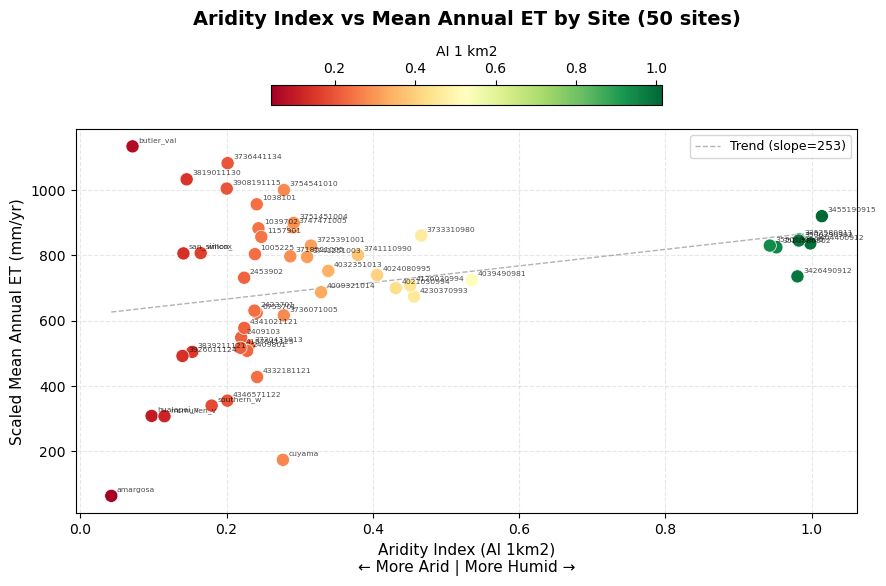

In [13]:
df = pd.read_csv('/capstone/aridgw/data/site_data/aridity_index_sites/sites_aridity_1km2.csv')
sites = df.groupby('site_id').agg(
    AI_1km2=('AI_1km2', 'first'),
    scaled_annual_et_avg=('scaled_annual_et_avg', 'mean')
).reset_index()

cmap = cm.RdYlGn
norm = plt.Normalize(sites['AI_1km2'].min(), sites['AI_1km2'].max())

fig, ax = plt.subplots(figsize=(9, 6))

sc = ax.scatter(
    sites['AI_1km2'], sites['scaled_annual_et_avg'],
    c=sites['AI_1km2'], cmap=cmap, norm=norm,
    s=90, edgecolors='white', linewidths=0.5, zorder=3
)

for _, row in sites.iterrows():
    short = row['site_id'].split('.')[-1][:10]
    ax.annotate(short, (row['AI_1km2'], row['scaled_annual_et_avg']),
                fontsize=5.5, alpha=0.7, textcoords='offset points', xytext=(4, 3))

m, b = np.polyfit(sites['AI_1km2'], sites['scaled_annual_et_avg'], 1)
x_line = np.linspace(sites['AI_1km2'].min(), sites['AI_1km2'].max(), 100)
ax.plot(x_line, m * x_line + b, color='gray', linestyle='--', linewidth=1, alpha=0.6, label=f'Trend (slope={m:.0f})')

# Bar Location
cbar = plt.colorbar(sc, ax=ax, location='top', shrink=0.5)
# Size and Title
cbar.set_label('AI 1 km2', fontsize=10)

ax.set_title('Aridity Index vs Mean Annual ET by Site (50 sites)', fontsize=14, pad=75, fontweight='bold')


ax.set_xlabel('Aridity Index (AI 1km2)\n← More Arid | More Humid →', fontsize=11)
ax.set_ylabel('Scaled Mean Annual ET (mm/yr)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
#plt.savefig('ai_vs_et.png', dpi=150)
plt.show()

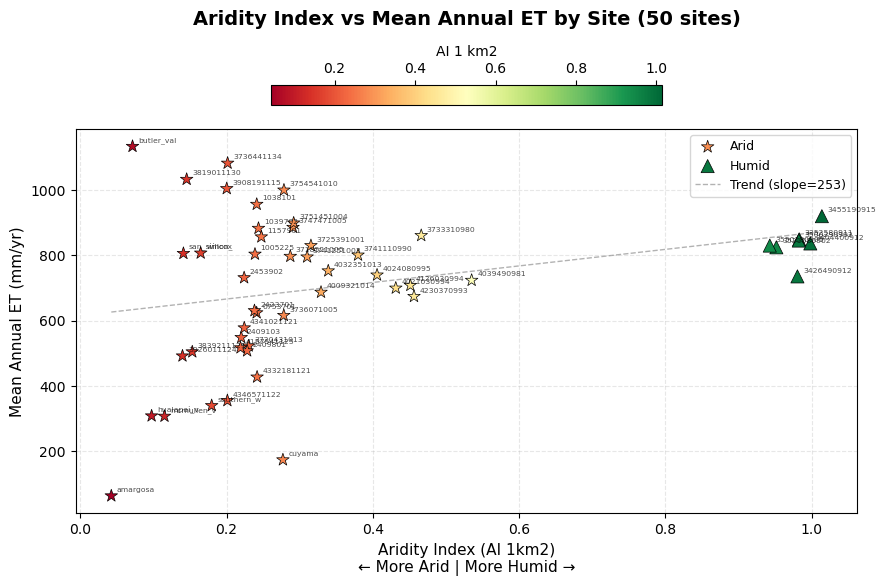

In [14]:
df = pd.read_csv('/capstone/aridgw/data/site_data/aridity_index_sites/sites_aridity_1km2.csv')
sites = df.groupby('site_id').agg(
    AI_1km2=('AI_1km2', 'first'),
    scaled_annual_et_avg=('scaled_annual_et_avg', 'mean')
).reset_index()

cmap = cm.RdYlGn
norm = plt.Normalize(sites['AI_1km2'].min(), sites['AI_1km2'].max())

arid = sites[sites['AI_1km2'] < 0.6]
humid = sites[sites['AI_1km2'] >= 0.6]

fig, ax = plt.subplots(figsize=(9, 6))

sc = ax.scatter(arid['AI_1km2'], arid['scaled_annual_et_avg'],
                c=arid['AI_1km2'], cmap=cmap, norm=norm,
                marker='*', s=90, edgecolors='black', linewidths=0.5, zorder=3, label='Arid')

ax.scatter(humid['AI_1km2'], humid['scaled_annual_et_avg'],
           c=humid['AI_1km2'], cmap=cmap, norm=norm,
           marker='^', s=90, edgecolors='black', linewidths=0.5, zorder=3, label='Humid')

for _, row in sites.iterrows():
    short = row['site_id'].split('.')[-1][:10]
    ax.annotate(short, (row['AI_1km2'], row['scaled_annual_et_avg']),
                fontsize=5.5, alpha=0.7, textcoords='offset points', xytext=(4, 3))

m, b = np.polyfit(sites['AI_1km2'], sites['scaled_annual_et_avg'], 1)
x_line = np.linspace(sites['AI_1km2'].min(), sites['AI_1km2'].max(), 100)
ax.plot(x_line, m * x_line + b, color='gray', linestyle='--', linewidth=1, alpha=0.6, label=f'Trend (slope={m:.0f})')

cbar = plt.colorbar(sc, ax=ax, location='top', shrink=0.5)
cbar.set_label('AI 1 km2', fontsize=10)

ax.set_title('Aridity Index vs Mean Annual ET by Site (50 sites)', fontsize=14, pad=75, fontweight='bold')
ax.set_xlabel('Aridity Index (AI 1km2)\n← More Arid | More Humid →', fontsize=11)
ax.set_ylabel('Mean Annual ET (mm/yr)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Plot AI and Mean ET (mm/yr)

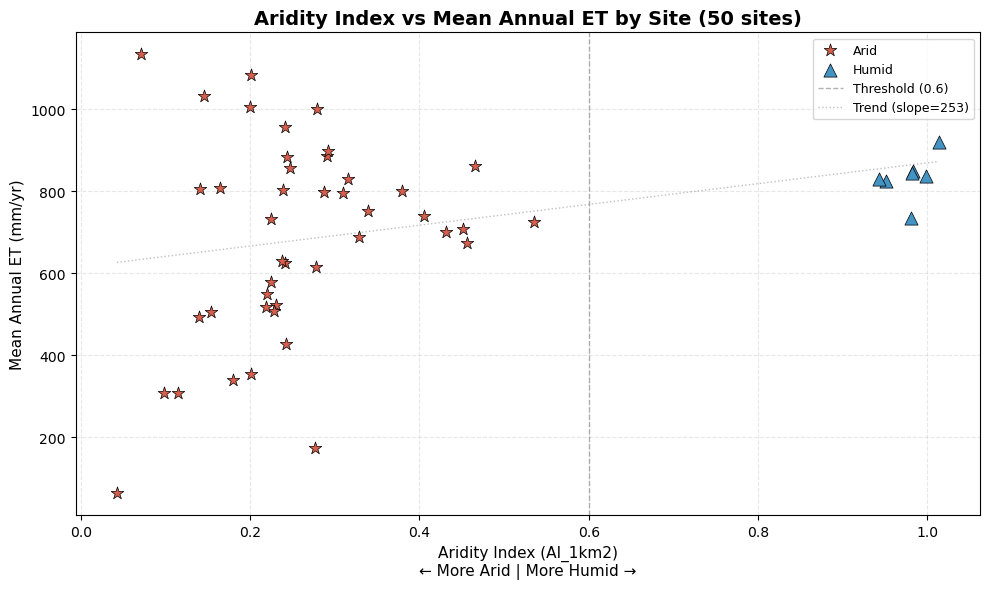

In [15]:
df = pd.read_csv("/capstone/aridgw/data/site_data/aridity_index_sites/sites_aridity_1km2.csv")

sites = df.groupby('site_id').agg(
    AI_1km2=('AI_1km2', 'first'),
    scaled_annual_et_avg=('scaled_annual_et_avg', 'mean')
).reset_index()

colors = sites['AI_1km2'].apply(lambda x: '#4393c3' if  # Humid
                                x >= 0.6 else '#d6604d') # Arid

fig, ax = plt.subplots(figsize=(10, 6))

arid = sites[sites['AI_1km2'] < 0.6]
humid = sites[sites['AI_1km2'] >= 0.6]

ax.scatter(arid['AI_1km2'], arid['scaled_annual_et_avg'],
           color='#d6604d', marker='*', s=90, edgecolors='black', linewidths=0.5, zorder=3, label='Arid')
ax.scatter(humid['AI_1km2'], humid['scaled_annual_et_avg'],
           color='#4393c3', marker='^', s=90, edgecolors='black', linewidths=0.5, zorder=3, label='Humid')

# ax.scatter(sites['AI_1km2'], sites['scaled_annual_et_avg'], marker = "*",
#            color=colors, s=90, edgecolors='white', linewidths=0.5, zorder=3)

ax.axvline(x=0.6, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='Threshold (0.6)')

m, b = np.polyfit(sites['AI_1km2'], sites['scaled_annual_et_avg'], 1)
x_line = np.linspace(sites['AI_1km2'].min(), sites['AI_1km2'].max(), 100)
ax.plot(x_line, m * x_line + b, color='gray', linestyle=':', linewidth=1, alpha=0.5, label=f'Trend (slope={m:.0f})')

ax.set_xlabel('Aridity Index (AI_1km2)\n← More Arid | More Humid →', fontsize=11)
ax.set_ylabel('Mean Annual ET (mm/yr)', fontsize=11)
ax.set_title('Aridity Index vs Mean Annual ET by Site (50 sites)', fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
#plt.savefig('ai_vs_et_region.png', dpi=150)
plt.show()

# AI for 4 km^2 

In [ ]:
# Retrieving CSV and TIF from Cyberduck
SITES_CSV = "/capstone/aridgw/raw_data/1km/openet_data_monthly_4km.csv"         # UPDATE WHEN OPENET CSV IS READY
ARIDITY_TIF = "/capstone/aridgw/raw_data/Global_Aridity_Index/Global-AI_ET0__annual_v3_1/ai_v31_yr.tif"
# CSV being saved in CyberDuck - Using Path
OUTPUT_CSV = "/capstone/aridgw/outputs/1km/sites_aridity_4km2.csv"
# Bounding Box
BBOX_KM = 2        # side length (km) producing 4km2 area
AREA_LABEL = "4km2"
AI_SCALE = 10_000.0   # raw values are AI * 10000


def km_to_deg(km: float, latitude: float) -> tuple[float, float]:
    """Convert km offset to degrees lat/lon at a given latitude."""
    lat_deg = km / 111.0
    lon_deg = km / (111.0 * np.cos(np.radians(latitude)))
    return lat_deg, lon_deg


def extract_mean_aridity(src: rasterio.DatasetReader, lat: float, lon: float) -> float:
    """Extract mean aridity index within BBOX_KM around a point."""
    half = BBOX_KM / 2
    lat_off, lon_off = km_to_deg(half, lat)

    window = from_bounds(
        left=lon - lon_off,
        bottom=lat - lat_off,
        right=lon + lon_off,
        top=lat + lat_off,
        transform=src.transform
    )
    data = src.read(1, window=window).astype(float)
    data[data == 0] = np.nan  # 0 is nodata in this dataset

    if np.all(np.isnan(data)):
        return np.nan

    return float(np.nanmean(data)) / AI_SCALE


def main():
    df = pd.read_csv(SITES_CSV)
    sites = df[["site_id", "latitude", "longitude"]].drop_duplicates().copy()

    print(f"Extracting AI_{AREA_LABEL} for {len(sites)} sites...")

    with rasterio.open(ARIDITY_TIF) as src:
        sites[f"AI_{AREA_LABEL}"] = sites.apply(
            lambda row: extract_mean_aridity(src, row["latitude"], row["longitude"]),
            axis=1
        )

    result = df.merge(sites[["site_id", f"AI_{AREA_LABEL}"]], on="site_id", how="left")
    result.to_csv(OUTPUT_CSV, index=False)

    print(f"Saved: {OUTPUT_CSV}")
    print(result[["site_id", "latitude", "longitude", f"AI_{AREA_LABEL}"]].drop_duplicates().to_string())


if __name__ == "__main__":
    main()

Extracting AI_4km2 for 50 sites...
Saved: /capstone/aridgw/data/site_data/aridity_index_sites/sites_aridity_4km2.csv
                    site_id   latitude   longitude   AI_4km2
0      KSGS.371852100505801  37.315020 -100.850500  0.288667
21     KSGS.372043101363101  37.344950 -101.610400  0.230800
42     KSGS.372539100142504  37.429490 -100.243400  0.314567
63     KSGS.373331098033301  37.560960  -98.058000  0.466383
84     KSGS.373607100565301  37.598740 -100.949700  0.278783
105    KSGS.374111099070401  37.684480  -99.119250  0.380217
126    KSGS.374125100344101  37.690240 -100.579500  0.309900
147    KSGS.374747100552101  37.794920 -100.922500  0.290283
168    KSGS.375145100485701  37.862090 -100.817900  0.292417
189    KSGS.375454101075401  37.915720 -101.130600  0.278600
210            TWDB.0753701  35.160000 -102.488600  0.240800
231            TWDB.1005225  34.970000 -102.438100  0.238567
252            TWDB.1038101  34.460000 -102.352200  0.240000
273            TWDB.1039702  

# Scatter Plots - AI 4 km2

In [17]:
df = pd.read_csv('/capstone/aridgw/data/site_data/aridity_index_sites/sites_aridity_4km2.csv')
sites = df.groupby('site_id').agg(
    AI_4km2=('AI_4km2', 'first'),
    scaled_annual_et_avg=('scaled_annual_et_avg', 'mean')
).reset_index()

cmap = cm.RdYlGn
norm = plt.Normalize(sites['AI_4km2'].min(), sites['AI_4km2'].max())

fig, ax = plt.subplots(figsize=(9, 6))

sc = ax.scatter(
    sites['AI_4km2'], sites['scaled_annual_et_avg'],
    c=sites['AI_4km2'], cmap=cmap, norm=norm,
    s=90, edgecolors='white', linewidths=0.5, zorder=3
)

for _, row in sites.iterrows():
    short = row['site_id'].split('.')[-1][:10]
    ax.annotate(short, (row['AI_4km2'], row['scaled_annual_et_avg']),
                fontsize=5.5, alpha=0.7, textcoords='offset points', xytext=(4, 3))

m, b = np.polyfit(sites['AI_4km2'], sites['scaled_annual_et_avg'], 1)
x_line = np.linspace(sites['AI_4km2'].min(), sites['AI_4km2'].max(), 100)
ax.plot(x_line, m * x_line + b, color='gray', linestyle='--', linewidth=1, alpha=0.6, label=f'Trend (slope={m:.0f})')

# Bar Location
cbar = plt.colorbar(sc, ax=ax, location='top', shrink=0.5)
# Size and Title
cbar.set_label('AI 4 km2', fontsize=10)

ax.set_title('Aridity Index vs Mean Annual ET by Site (50 sites)', fontsize=14, pad=75, fontweight='bold')


ax.set_xlabel('AI 4 km2 \n← More Arid | More Humid →', fontsize=11)
ax.set_ylabel('Mean Annual ET (mm/yr)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
#plt.savefig('ai_vs_et.png', dpi=150)
plt.show()

KeyError: "Column(s) ['scaled_annual_et_avg'] do not exist"

# AI for 16 km^2 

In [ ]:
# Retrieving CSV and TIF from Cyberduck
SITES_CSV = "/capstone/aridgw/data/openet_merged_timeseries_1km/merged_openet_data.csv" # UPDATE WHEN OPENET CSV IS READY

ARIDITY_TIF = "/capstone/aridgw/data/Global_Aridity_Index/Global-AI_ET0__annual_v3_1/ai_v31_yr.tif"
# CSV being saved in CyberDuck - Using Path
OUTPUT_CSV = "/capstone/aridgw/data/site_data/aridity_index_sites/sites_aridity_16km2.csv"
# Bounding box
BBOX_KM = 4        # side length (km) producing 16km2 area
AREA_LABEL = "16km2"
AI_SCALE = 10_000.0   # raw values are AI * 10000


def km_to_deg(km: float, latitude: float) -> tuple[float, float]:
    """Convert km offset to degrees lat/lon at a given latitude."""
    lat_deg = km / 111.0
    lon_deg = km / (111.0 * np.cos(np.radians(latitude)))
    return lat_deg, lon_deg


def extract_mean_aridity(src: rasterio.DatasetReader, lat: float, lon: float) -> float:
    """Extract mean aridity index within BBOX_KM around a point."""
    half = BBOX_KM / 2
    lat_off, lon_off = km_to_deg(half, lat)

    window = from_bounds(
        left=lon - lon_off,
        bottom=lat - lat_off,
        right=lon + lon_off,
        top=lat + lat_off,
        transform=src.transform
    )
    data = src.read(1, window=window).astype(float)
    data[data == 0] = np.nan  # 0 is nodata in this dataset

    if np.all(np.isnan(data)):
        return np.nan

    return float(np.nanmean(data)) / AI_SCALE


def main():
    df = pd.read_csv(SITES_CSV)
    sites = df[["site_id", "latitude", "longitude"]].drop_duplicates().copy()

    print(f"Extracting AI_{AREA_LABEL} for {len(sites)} sites...")

    with rasterio.open(ARIDITY_TIF) as src:
        sites[f"AI_{AREA_LABEL}"] = sites.apply(
            lambda row: extract_mean_aridity(src, row["latitude"], row["longitude"]),
            axis=1
        )

    result = df.merge(sites[["site_id", f"AI_{AREA_LABEL}"]], on="site_id", how="left")
    #result.to_csv(OUTPUT_CSV, index=False)

    #print(f"Saved: {OUTPUT_CSV}")
    print(result[["site_id", "latitude", "longitude", f"AI_{AREA_LABEL}"]].drop_duplicates().to_string())


if __name__ == "__main__":
    main()

In [ ]:
df = pd.read_csv("/capstone/aridgw/data/site_data/aridity_index_sites/sites_aridity_16km2.csv")
sites = df.groupby('site_id').agg(
    AI_16km2=('AI_16km2', 'first'),
    annual_et_mm_yr=('annual_et_mm_yr', 'mean')
).reset_index()

cmap = cm.RdYlGn
norm = plt.Normalize(sites['AI_16km2'].min(), sites['AI_16km2'].max())


fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(
    sites['AI_16km2'], sites['annual_et_mm_yr'],
    c=sites['AI_16km2'], cmap=cmap, norm=norm,
    s=90, edgecolors='white', linewidths=0.5, zorder=3
)

# Add labels, when regions are ready
# for _, row in sites.iterrows():
#     short = row['site_id'].split('.')[-1][:10]
#     ax.annotate(short, (row['AI_16km2'], row['annual_et_mm_yr']),
#                 fontsize=5.5, alpha=0.7, textcoords='offset points', xytext=(4, 3))

m, b = np.polyfit(sites['AI_16km2'], sites['annual_et_mm_yr'], 1)
x_line = np.linspace(sites['AI_16km2'].min(), sites['AI_16km2'].max(), 100)

# Trend Line
ax.plot(x_line, m * x_line + b, color='gray', linestyle='--', linewidth=1, alpha=0.6, label=f'Trend (slope={m:.0f})')


cbar = plt.colorbar(sc, ax=ax, location='top', shrink=0.5)
cbar.set_label('AI 16 km2', fontsize=10)

ax.set_title('Aridity Index vs Mean Annual ET by Site (50 sites)', fontsize=14, pad=75, fontweight='bold')

ax.set_xlabel('Aridity Index (AI_16km2)\n← More Arid | More Humid →', fontsize=11)
ax.set_ylabel('Mean Annual ET (mm/yr)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
#plt.savefig('ai_vs_et.png', dpi=150)
plt.show()


In [ ]:
df = pd.read_csv("/capstone/aridgw/data/site_data/aridity_index_sites/sites_aridity_16km2.csv")
sites = df.groupby('site_id').agg(
    AI_16km2=('AI_16km2', 'first'),
    annual_et_mm_yr=('annual_et_mm_yr', 'mean')
).reset_index()

cmap = cm.RdYlGn
norm = plt.Normalize(sites['AI_16km2'].min(), sites['AI_16km2'].max())


fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(
    sites['AI_16km2'], sites['annual_et_mm_yr'],
    c=sites['AI_16km2'], cmap=cmap, norm=norm,
    s=90, edgecolors='white', linewidths=0.5, zorder=3
)

# Add labels, when regions are ready
# for _, row in sites.iterrows():
#     short = row['site_id'].split('.')[-1][:10]
#     ax.annotate(short, (row['AI_16km2'], row['annual_et_mm_yr']),
#                 fontsize=5.5, alpha=0.7, textcoords='offset points', xytext=(4, 3))

m, b = np.polyfit(sites['AI_16km2'], sites['annual_et_mm_yr'], 1)
x_line = np.linspace(sites['AI_16km2'].min(), sites['AI_16km2'].max(), 100)

# Trend Line
ax.plot(x_line, m * x_line + b, color='gray', linestyle='--', linewidth=1, alpha=0.6, label=f'Trend (slope={m:.0f})')


cbar = plt.colorbar(sc, ax=ax, location='top', shrink=0.5)
cbar.set_label('AI 16 km2', fontsize=10)

ax.set_title('Aridity Index vs Mean Annual ET by Site (50 sites)', fontsize=14, pad=75, fontweight='bold')

ax.set_xlabel('Aridity Index (AI 16km2)\n← More Arid | More Humid →', fontsize=11)
ax.set_ylabel('Mean Annual ET (mm/yr)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
#plt.savefig('ai_vs_et.png', dpi=150)
plt.show()

# AI for 100 km^2 

In [ ]:
# Retrieving CSV and TIF from Cyberduck
SITES_CSV = "/capstone/aridgw/data/openet_merged_timeseries_1km/merged_openet_data.csv" # UPDATE WHEN OPENET CSV IS READY
ARIDITY_TIF = "/capstone/aridgw/data/Global_Aridity_Index/Global-AI_ET0__annual_v3_1/ai_v31_yr.tif"
# CSV being saved in CyberDuck - Using Path
OUTPUT_CSV = "/capstone/aridgw/data/site_data/aridity_index_sites/sites_aridity_100km2.csv"
# Bounding Box
BBOX_KM = 10        # side length (km) producing 100km2 area
AREA_LABEL = "100km2"
AI_SCALE = 10_000.0   # raw values are AI * 10000


def km_to_deg(km: float, latitude: float) -> tuple[float, float]:
    """Convert km offset to degrees lat/lon at a given latitude."""
    lat_deg = km / 111.0
    lon_deg = km / (111.0 * np.cos(np.radians(latitude)))
    return lat_deg, lon_deg


def extract_mean_aridity(src: rasterio.DatasetReader, lat: float, lon: float) -> float:
    """Extract mean aridity index within BBOX_KM around a point."""
    half = BBOX_KM / 2
    lat_off, lon_off = km_to_deg(half, lat)

    window = from_bounds(
        left=lon - lon_off,
        bottom=lat - lat_off,
        right=lon + lon_off,
        top=lat + lat_off,
        transform=src.transform
    )
    data = src.read(1, window=window).astype(float)
    data[data == 0] = np.nan  # 0 is nodata in this dataset

    if np.all(np.isnan(data)):
        return np.nan

    return float(np.nanmean(data)) / AI_SCALE


def main():
    df = pd.read_csv(SITES_CSV)
    sites = df[["site_id", "latitude", "longitude"]].drop_duplicates().copy()

    print(f"Extracting AI_{AREA_LABEL} for {len(sites)} sites...")

    with rasterio.open(ARIDITY_TIF) as src:
        sites[f"AI_{AREA_LABEL}"] = sites.apply(
            lambda row: extract_mean_aridity(src, row["latitude"], row["longitude"]),
            axis=1
        )

    result = df.merge(sites[["site_id", f"AI_{AREA_LABEL}"]], on="site_id", how="left")
    #result.to_csv(OUTPUT_CSV, index=False)

    #print(f"Saved: {OUTPUT_CSV}")
    print(result[["site_id", "latitude", "longitude", f"AI_{AREA_LABEL}"]].drop_duplicates().to_string())


if __name__ == "__main__":
    main()

In [ ]:
df = pd.read_csv("/capstone/aridgw/data/site_data/aridity_index_sites/sites_aridity_100km2.csv")
sites = df.groupby('site_id').agg(
    AI_100km2=('AI_100km2', 'first'),
    annual_et_mm_yr=('annual_et_mm_yr', 'mean')
).reset_index()

cmap = cm.RdYlGn
norm = plt.Normalize(sites['AI_100km2'].min(), sites['AI_100km2'].max())


fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(
    sites['AI_100km2'], sites['annual_et_mm_yr'],
    c=sites['AI_100km2'], cmap=cmap, norm=norm,
    s=90, edgecolors='white', linewidths=0.5, zorder=3
)

# Add labels, when regions are ready
# for _, row in sites.iterrows():
#     short = row['site_id'].split('.')[-1][:10]
#     ax.annotate(short, (row['AI_16km2'], row['annual_et_mm_yr']),
#                 fontsize=5.5, alpha=0.7, textcoords='offset points', xytext=(4, 3))

m, b = np.polyfit(sites['AI_100km2'], sites['annual_et_mm_yr'], 1)
x_line = np.linspace(sites['AI_100km2'].min(), sites['AI_100km2'].max(), 100)

# Trend Line
ax.plot(x_line, m * x_line + b, color='gray', linestyle='--', linewidth=1, alpha=0.6, label=f'Trend (slope={m:.0f})')


cbar = plt.colorbar(sc, ax=ax, location='top', shrink=0.5)
cbar.set_label('AI 100 km2', fontsize=10)

ax.set_title('Aridity Index vs Mean Annual ET by Site (50 sites)', fontsize=14, pad=75, fontweight='bold')

ax.set_xlabel('Aridity Index (AI_100km2)\n← More Arid | More Humid →', fontsize=11)
ax.set_ylabel('Mean Annual ET (mm/yr)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
#plt.savefig('ai_vs_et.png', dpi=150)
plt.show()


# All Bounding Boxes Combined 

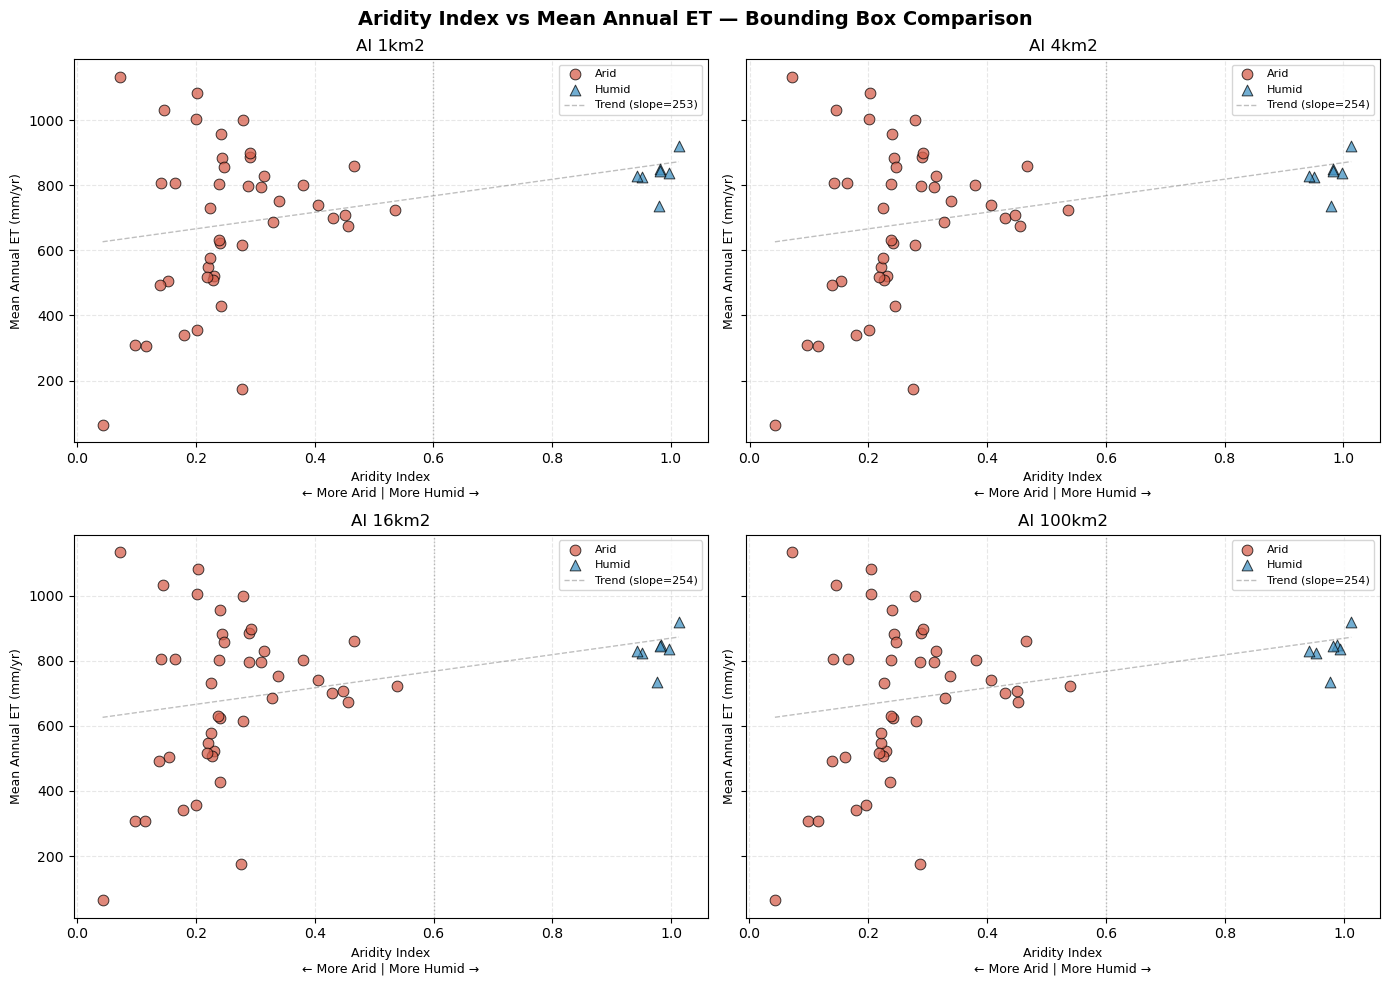

In [18]:
#SITES_CSV_OLDDD = "/capstone/aridgw/data/openet_merged_timeseries_1km/merged_openet_data.csv"
SITES_CSV = "/capstone/aridgw/data//openet_merged_timeseries_1km/merged_openet_data_1km.csv"

ARIDITY_TIF = "/capstone/aridgw/data/Global_Aridity_Index/Global-AI_ET0__annual_v3_1/ai_v31_yr.tif"
AI_SCALE = 10_000.0

CONFIGS = [
    {"bbox_km": 1,  "label": "1km2"},
    {"bbox_km": 2,  "label": "4km2"},
    {"bbox_km": 4,  "label": "16km2"},
    {"bbox_km": 10, "label": "100km2"},
]


def km_to_deg(km, latitude):
    lat_deg = km / 111.0
    lon_deg = km / (111.0 * np.cos(np.radians(latitude)))
    return lat_deg, lon_deg


def extract_mean_aridity(src, lat, lon, bbox_km):
    half = bbox_km / 2
    lat_off, lon_off = km_to_deg(half, lat)
    window = from_bounds(
        left=lon - lon_off, bottom=lat - lat_off,
        right=lon + lon_off, top=lat + lat_off,
        transform=src.transform
    )
    data = src.read(1, window=window).astype(float)
    data[data == 0] = np.nan
    if np.all(np.isnan(data)):
        return np.nan
    return float(np.nanmean(data)) / AI_SCALE


df = pd.read_csv(SITES_CSV)
sites_base = df[["site_id", "latitude", "longitude"]].drop_duplicates().copy()
et = df.groupby('site_id').agg(scaled_annual_et_avg=('scaled_annual_et_avg', 'mean')).reset_index()

fig, axs = plt.subplots(2, 2, figsize=(14, 10), sharex=False, sharey=True)
axs = axs.flatten()

with rasterio.open(ARIDITY_TIF) as src:
    for i, cfg in enumerate(CONFIGS):
        sites = sites_base.copy()
        col = f"AI_{cfg['label']}"
        sites[col] = sites.apply(
            lambda row: extract_mean_aridity(src, row["latitude"], row["longitude"], cfg["bbox_km"]),
            axis=1
        )
        sites = sites.merge(et, on='site_id')

        arid = sites[sites[col] < 0.6]
        humid = sites[sites[col] >= 0.6]
        ax = axs[i]

        ax.scatter(arid[col], arid['scaled_annual_et_avg'],
                   color='#d6604d', marker='o', s=60, edgecolors='black', linewidths=0.7, zorder=3, label='Arid', alpha = 0.75)
        ax.scatter(humid[col], humid['scaled_annual_et_avg'],
                   color='#4393c3', marker='^', s=60, edgecolors='black', linewidths=0.7, zorder=3, label='Humid', alpha = 0.75)

        m, b = np.polyfit(sites[col], sites['scaled_annual_et_avg'], 1)
        x_line = np.linspace(sites[col].min(), sites[col].max(), 100)
        ax.plot(x_line, m * x_line + b, color='gray', linestyle='--', linewidth=1, alpha=0.5, label=f'Trend (slope={m:.0f})')

        ax.axvline(x=0.6, color='gray', linestyle=':', linewidth=1, alpha=0.5)
        ax.set_title(f'AI {cfg["label"]}', fontsize=12)
        ax.set_xlabel('Aridity Index\n← More Arid | More Humid →', fontsize=9)
        ax.set_ylabel('Mean Annual ET (mm/yr)', fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(True, linestyle='--', alpha=0.3)

fig.suptitle('Aridity Index vs Mean Annual ET — Bounding Box Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
#plt.savefig('ai_vs_et_comparison.png', dpi=150)
plt.show()

# ET:Precip Ratio with AI PLOT

In [19]:
# Load in ET:Precip from Cyberduck
et = pd.read_csv("/capstone/aridgw/data/ET_precipt_USGS_sites.csv")

# View shape
et.shape # 50 Rows, 5 Column


# View first 5 rows
et.head()

,site_id,gw_trend_m_per_yr,mean_et,mean_precip,et_precip_ratio
0,KSGS.371852100505801,0.616701,797.106238,551.83820,1.444456
1,KSGS.372043101363101,0.213301,522.713143,514.42303,1.016115
2,KSGS.372539100142504,1.047972,829.910619,605.14417,1.371426
3,KSGS.373331098033301,0.063359,860.773810,929.18040,0.926380
4,KSGS.373607100565301,0.595615,616.277619,523.98620,1.176133


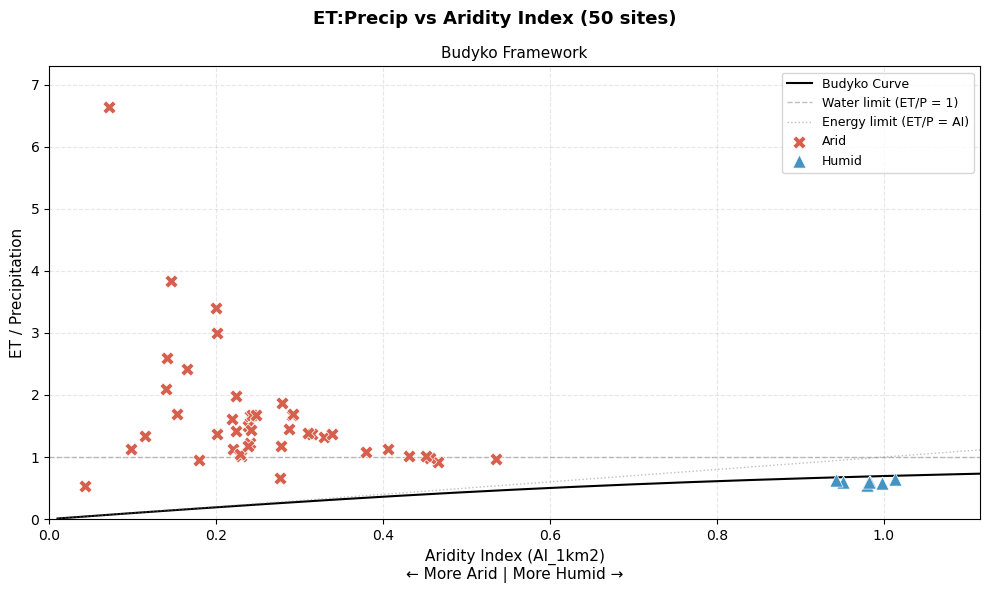

In [20]:
ai = pd.read_csv("/capstone/aridgw/data/site_data/aridity_index_sites/sites_aridity_1km2.csv")
sites_ai = ai.groupby('site_id').agg(AI_1km2=('AI_1km2', 'first')).reset_index()
et = pd.read_csv("/capstone/aridgw/data/ET_precipt_USGS_sites.csv")

df = et.merge(sites_ai, on='site_id')

# Budyko curve: ET/P = (AI * tanh(1/AI) * (1 - exp(-AI)))^0.5
ai_curve = np.linspace(0.01, 7, 500)
budyko = np.sqrt(ai_curve * np.tanh(1 / ai_curve) * (1 - np.exp(-ai_curve)))

# 
colors = df['AI_1km2'].apply(lambda x: '#4393c3' if # Humid
                             x >= 0.6 else '#d6604d') # Arid


fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(ai_curve, budyko, 'k-', linewidth=1.5, label='Budyko Curve', zorder=2)
ax.axhline(y=1, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Water limit (ET/P = 1)')
ax.plot(ai_curve, np.minimum(ai_curve, np.ones_like(ai_curve) * max(df['et_precip_ratio']) * 1.1),
        color='gray', linestyle=':', linewidth=1, alpha=0.5, label='Energy limit (ET/P = AI)')

# Set threshold to 0.6
arid = df[df['AI_1km2'] < 0.6]
humid = df[df['AI_1km2'] >= 0.6]

ax.scatter(arid['AI_1km2'], arid['et_precip_ratio'],
           color='#d6604d', marker='X', s=90, edgecolors='white', linewidths=0.5, zorder=3, label='Arid')
ax.scatter(humid['AI_1km2'], humid['et_precip_ratio'],
           color='#4393c3', marker='^', s=90, edgecolors='white', linewidths=0.5, zorder=3, label='Humid')

ax.set_xlabel('Aridity Index (AI_1km2)\n← More Arid | More Humid →', fontsize=11)
ax.set_ylabel('ET / Precipitation', fontsize=11)
#ax.set_title('ET:Precip vs Aridity Index (50 sites)', fontsize=14, fontweight='bold')
ax.set_xlim(0, df['AI_1km2'].max() * 1.1)
ax.set_ylim(0, df['et_precip_ratio'].max() * 1.1)
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.3)

fig.suptitle('ET:Precip vs Aridity Index (50 sites)', fontsize=13, fontweight='bold')
ax.set_title('Budyko Framework', fontsize=11)

plt.tight_layout()
#plt.savefig('budyko.png', dpi=150)
plt.show()

# Spearman Rank Correlation, AI, Budyko Curve 


## Create Budyko Curve CSV
Aridity Index (AI) and ET:Precip

In [22]:
# --- File paths ---
ARIDITY_CSV  = "/capstone/aridgw/data/site_data/aridity_index_sites/sites_aridity_1km2.csv"
ET_CSV       = "/capstone/aridgw/data/ET_precipt_USGS_sites.csv"
MERGED_CSV   = "/capstone/aridgw/data/site_data/budyko_1km2_merged.csv"
SPEARMAN_CSV = "/capstone/aridgw/data/site_data/spearman_results_1km2.csv"
#FIGURE_PATH  = "/capstone/aridgw/data/figures/budyko_1km2_byregion.png"


# ============================================================
# Merge AI and ET:Precip into one CSV
# ============================================================
ai = pd.read_csv(ARIDITY_CSV)
sites_ai = ai.groupby('site_id').agg(
    AI_1km2=('AI_1km2', 'first'),
    latitude=('latitude', 'first'),
    longitude=('longitude', 'first'),
    region=('region', 'first')
).reset_index()

et = pd.read_csv(ET_CSV)
df = et.merge(sites_ai, on='site_id')
#df.to_csv(MERGED_CSV, index=False)
#print(f"Merged CSV saved: {MERGED_CSV}")
print(f"Shape: {df.shape}, Columns: {df.columns.tolist()}\n")


Shape: (50, 9), Columns: ['site_id', 'gw_trend_m_per_yr', 'mean_et', 'mean_precip', 'et_precip_ratio', 'AI_1km2', 'latitude', 'longitude', 'region']



In [23]:
# ============================================================
# Spearman Rank Correlations
# ============================================================
spearman_results = []

# All 50 sites
for var_x, var_y in [('AI_1km2',        'et_precip_ratio'),
                     ('et_precip_ratio', 'gw_trend_m_per_yr'),
                     ('AI_1km2',         'gw_trend_m_per_yr')]:
    rho, pval = spearmanr(df[var_x], df[var_y])
    spearman_results.append({
        'region':  'All sites',
        'x':       var_x,
        'y':       var_y,
        'n':       len(df),
        'rho':     round(rho, 4),
        'p_value': round(pval, 4)
    })

# By region (AI_1km2 vs et_precip_ratio)
for region in sorted(df['region'].unique()):
    sub = df[df['region'] == region]
    if len(sub) < 3:
        spearman_results.append({
            'region':  region,
            'x':       'AI_1km2',
            'y':       'et_precip_ratio',
            'n':       len(sub),
            'rho':     np.nan,
            'p_value': np.nan
        })
        continue
    rho, pval = spearmanr(sub['AI_1km2'], sub['et_precip_ratio'])
    spearman_results.append({
        'region':  region,
        'x':       'AI_1km2',
        'y':       'et_precip_ratio',
        'n':       len(sub),
        'rho':     round(rho, 4),
        'p_value': round(pval, 4)
    })

spearman_df = pd.DataFrame(spearman_results)
#spearman_df.to_csv(SPEARMAN_CSV, index=False)
#print(f"Spearman results saved: {SPEARMAN_CSV}")
print(spearman_df.to_string(index=False))

             region               x                 y  n     rho  p_value
          All sites         AI_1km2   et_precip_ratio 50 -0.5882   0.0000
          All sites et_precip_ratio gw_trend_m_per_yr 50  0.5236   0.0001
          All sites         AI_1km2 gw_trend_m_per_yr 50 -0.3766   0.0070
            Arizona         AI_1km2   et_precip_ratio  6 -0.4857   0.3287
     Arkansas Delta         AI_1km2   et_precip_ratio  7  0.1786   0.7017
   Central Nebraska         AI_1km2   et_precip_ratio  7 -0.9286   0.0025
 Southeastern Idaho         AI_1km2   et_precip_ratio  1     NaN      NaN
Southern California         AI_1km2   et_precip_ratio  2     NaN      NaN
     Southern Idaho         AI_1km2   et_precip_ratio  3  0.5000   0.6667
    Southern Kansas         AI_1km2   et_precip_ratio 10 -0.2606   0.4671
      Western Texas         AI_1km2   et_precip_ratio  9  0.8167   0.0072
       Western Utah         AI_1km2   et_precip_ratio  5  0.1000   0.8729


### Thoughts
- Southeastern Idaho (n=1) and Southern California (n=2) still produce NaN 
- Not enough sites in those regions for a correlation

# Budyko Plot colored by region

/tmp/ipykernel_2156061/985566342.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Set1', len(regions))


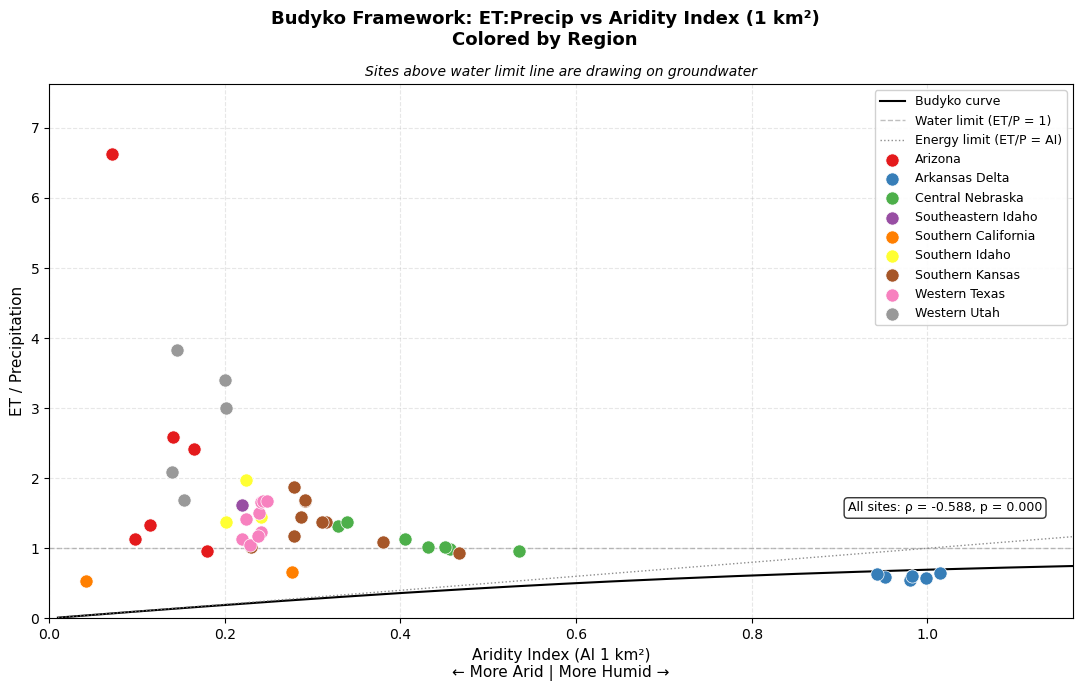

In [25]:
# ============================================================
# Budyko Plot
# ============================================================
regions = sorted(df['region'].unique())
cmap = cm.get_cmap('Set1', len(regions))
region_colors = {region: cmap(i) for i, region in enumerate(regions)}

ai_curve = np.linspace(0.01, 7, 500)
budyko = np.sqrt(ai_curve * np.tanh(1 / ai_curve) * (1 - np.exp(-ai_curve)))

fig, ax = plt.subplots(figsize=(11, 7))
ax.plot(ai_curve, budyko, 'k-', linewidth=1.5, label='Budyko curve', zorder=2)
ax.axhline(y=1, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Water limit (ET/P = 1)')
ax.plot(ai_curve, np.minimum(ai_curve, np.ones_like(ai_curve) * df['et_precip_ratio'].max() * 1.1),
        color='gray', linestyle=':', linewidth=1, alpha=0.9, label='Energy limit (ET/P = AI)')

for region, color in region_colors.items():
    sub = df[df['region'] == region]
    if sub.empty:
        continue
    ax.scatter(sub['AI_1km2'], sub['et_precip_ratio'],
               color=color, s=90, edgecolors='white', linewidths=0.5,
               zorder=3, label=region)

rho, pval = spearmanr(df['AI_1km2'], df['et_precip_ratio'])
ax.annotate(f'All sites: ρ = {rho:.3f}, p = {pval:.3f}',
            xy=(0.78, 0.20), xycoords='axes fraction', fontsize=9,
            ha='left', bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

ax.set_xlabel('Aridity Index (AI 1 km²)\n← More Arid | More Humid →', fontsize=11)
ax.set_ylabel('ET / Precipitation', fontsize=11)
ax.set_xlim(0, df['AI_1km2'].max() * 1.15)
ax.set_ylim(0, df['et_precip_ratio'].max() * 1.15)
#ax.invert_yaxis()
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.3)
fig.suptitle('Budyko Framework: ET:Precip vs Aridity Index (1 km²)\nColored by Region',
             fontsize=13, fontweight='bold')
ax.set_title('Sites above water limit line are drawing on groundwater',
             fontsize=10, style='italic')

plt.tight_layout()
plt.show()
#plt.savefig(FIGURE_PATH, dpi=150, bbox_inches='tight')
#print(f"Figure saved: {FIGURE_PATH}")

## What should we categorize gwl_trend to for rapid decline (Rapid, Minimize, no decline)?

- x-axis divide by 1
- color gradient of gwl


In [ ]:
df.head()